- Load dataset
- get example
- display blank grid
- display heatmap random + cheating
- display heatmap - blank

In [6]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

from compactreasoningmodels.solving_traces.arc_consistency import ArcConsistency
from compactreasoningmodels.solving_traces.local_min_violations import LocalMinViolations
from compactreasoningmodels.solving_traces.global_min_violations import GlobalMinViolations
from compactreasoningmodels.solving_traces.discrete_genetic import DiscreteGeneticAlgorithm
from compactreasoningmodels.datasets.jsonl import JsonlDataset
from compactreasoningmodels.utils.display import display_grid
os.environ["DATA_DIR"] = "../data/"

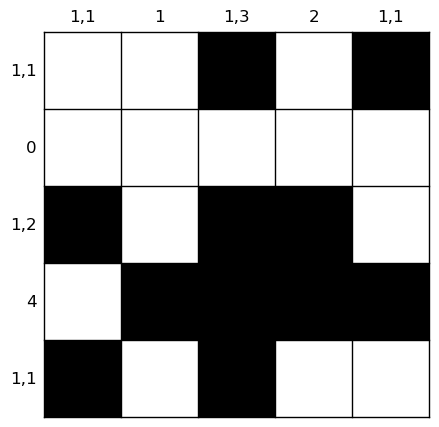

In [2]:
dataset = JsonlDataset("raw/nonogram_5x5_small.jsonl", target_shape=(5, 5))
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False) 
sample_clues, sample_grids = next(iter(dataloader))
sample_clues = sample_clues.squeeze(0).reshape(2, 5, 3)
sample_grids = sample_grids.squeeze(0)
fig, ax = plt.subplots(figsize=(5, 5))
display_grid(ax, sample_grids, clues=sample_clues, title='')

/home/cohen/PhD/CompactReasoningModels/src/compactreasoningmodels/solving_traces/local_min_violations.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.tensor_clues = torch.tensor(clues.flatten(), dtype=torch.float32).unsqueeze(0)
/home/cohen/PhD/CompactReasoningModels/src/compactreasoningmodels/solving_traces/global_min_violations.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.tensor_clues = torch.tensor(clues.flatten(), dtype=torch.float32).unsqueeze(0)


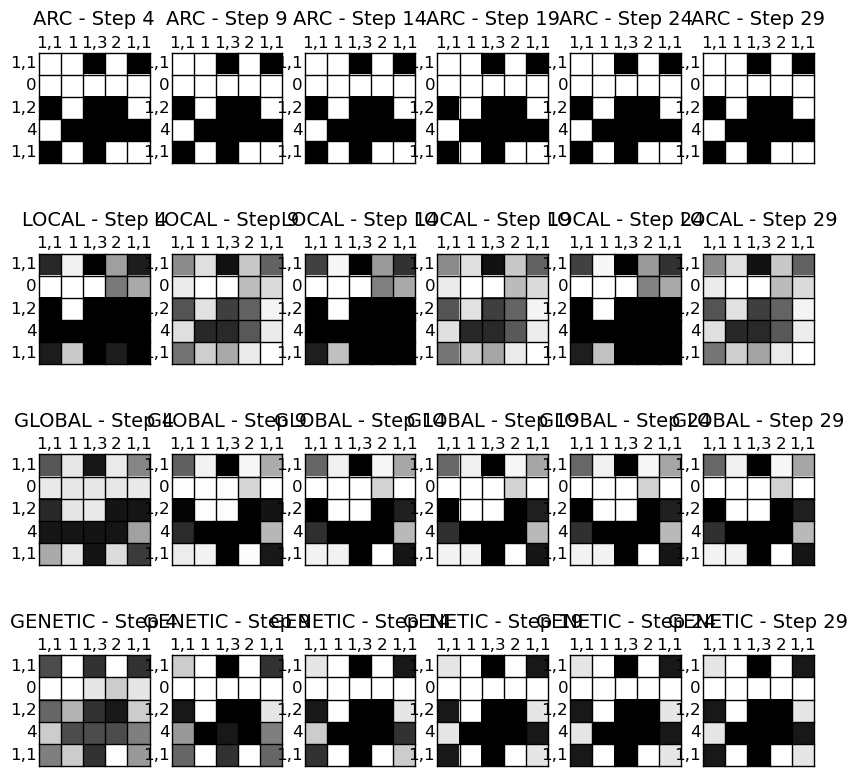

In [10]:
blank_grid = np.full((5, 5), 0.5)
all_solvers = {
    "ARC": ArcConsistency(sample_clues, (5,5)),
    "LOCAL": LocalMinViolations(sample_clues, (5,5)),
    "GLOBAL": GlobalMinViolations(sample_clues, (5,5)),
    "GENETIC": DiscreteGeneticAlgorithm(sample_clues, (5,5), population_size=1000, concurrent_samples=10, mutation_rate=0.01, tournament_size=3)
}
num_steps = 30
display_every = 5
alpha = 1.0
fig, axes = plt.subplots(len(all_solvers), num_steps // display_every, figsize=(10, 10))
for solver_name, solver in all_solvers.items():
    prev_heatmap = blank_grid
    for step in range(num_steps):
        heatmap = solver.heatmap_step(prev_heatmap)
        if step % display_every == display_every - 1:
            ax = axes[list(all_solvers.keys()).index(solver_name), step // display_every]
            display_grid(ax, heatmap, clues=sample_clues, title=f"{solver_name} - Step {step}")
        prev_heatmap = heatmap * alpha + prev_heatmap * (1 - alpha)